Final Project Draft: [Student Dropout Prediction]
Kennedy Madison
Due: 4/5/26

## 1. Problem Statement & Dataset
How can we predict whether a student will drop out of school and can we prevent it? The data set provides different demographics and categories that can help us identfy possible patterns of a student drop out incident]

In [91]:
## Data Loading & Exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
df = pd.read_csv("student_dropout_dataset_v3.csv") 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

df.head()
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  str    
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  str    
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  str    
 10  Scholarship            10000 non-null  str    
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Semester      

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


In [92]:
#This is the amount of missing values within each category
df.isnull().sum()


Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

In [93]:
# I had to fill in the missing values in the data set
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


C:\Users\kgmad\AppData\Local\Temp\ipykernel_20356\3034858899.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [94]:
#New data set, with no more missing values
df.isnull().sum()

Student_ID               0
Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Semester                 0
Department               0
Parental_Education       0
Dropout                  0
dtype: int64

In [95]:
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,29740.5,Yes,4.00,82.2,2,38.6,No,No,5.5,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [96]:
## 3. Feature Engineering
#does income level affect dropout rate?
df['low_income'] = (df['Family_Income'] < df['Family_Income'].median()).astype(int)

In [97]:
#Does stress level affect dropout rate?
df['high_stress'] = (df['Stress_Index'] >= 7).astype(int)

In [98]:
#academic performance comparison based on semester
df['gpa_gap'] = df['GPA'] - df['Semester_GPA']

In [99]:
#Scholarship vs no scholarship feature
df['has_scholarship'] = (df['Scholarship'] == 'Yes').astype(int)

In [100]:
#does the student have a part time job or not?
df['has_part_time_job'] = (df['Part_Time_Job'] == 'Yes').astype(int)


In [101]:
features = [
    'GPA',
    'Semester_GPA',
    'Stress_Index',
    'Family_Income',
    'gpa_gap',
    'high_stress',
    'low_income',
    'has_scholarship',
    'has_part_time_job'
]

X = df[features]
y = df['Dropout']

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [103]:
#Had to fill in missing values again after feature engineering
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test = X_test.fillna(X_train.median(numeric_only=True))

In [104]:
scaler = StandardScaler()

numeric_features = [
    'GPA',
    'Semester_GPA',
    'Stress_Index',
    'Family_Income',
    'gpa_gap'
]

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

In [105]:
rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("Best RF Params:", grid_rf.best_params_)
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Best RF Params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
RF Accuracy: 0.804
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      1529
           1       0.64      0.39      0.48       471

    accuracy                           0.80      2000
   macro avg       0.74      0.66      0.68      2000
weighted avg       0.79      0.80      0.79      2000



In [106]:
lr = LogisticRegression(max_iter=1000)

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    lr,
    param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_

y_pred_lr = best_lr.predict(X_test)

print("Best LR Params:", grid_lr.best_params_)
print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Best LR Params: {'C': 0.1, 'solver': 'lbfgs'}
LR Accuracy: 0.804
              precision    recall  f1-score   support

           0       0.83      0.94      0.88      1529
           1       0.65      0.35      0.46       471

    accuracy                           0.80      2000
   macro avg       0.74      0.65      0.67      2000
weighted avg       0.79      0.80      0.78      2000



In [116]:
comparison = pd.DataFrame({
    "Model": ["Tuned Random Forest", "Tuned Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lr)
    ]
})

comparison

,Model,Accuracy
0,Tuned Random Forest,0.804
1,Tuned Logistic Regression,0.804


<Figure size 640x480 with 0 Axes>

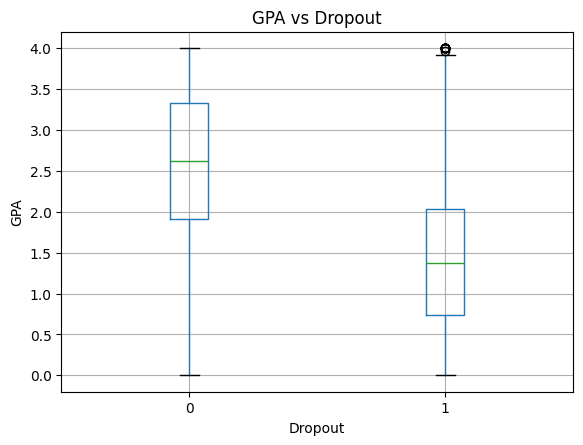

In [108]:
plt.figure()
df.boxplot(column='GPA', by='Dropout')
plt.title("GPA vs Dropout")
plt.suptitle("")
plt.xlabel("Dropout")
plt.ylabel("GPA")
plt.show()

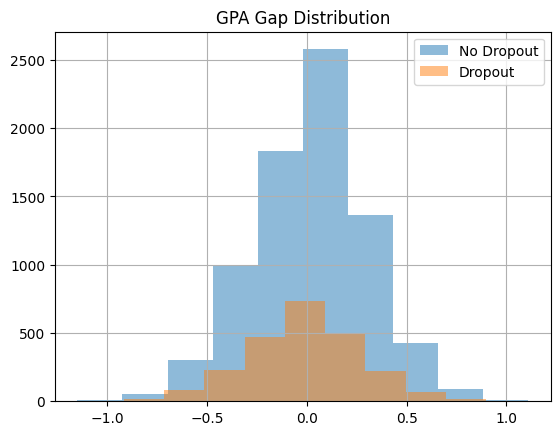

In [109]:
plt.figure()
df[df['Dropout'] == 0]['gpa_gap'].hist(alpha=0.5, label='No Dropout')
df[df['Dropout'] == 1]['gpa_gap'].hist(alpha=0.5, label='Dropout')
plt.legend()
plt.title("GPA Gap Distribution")
plt.show()

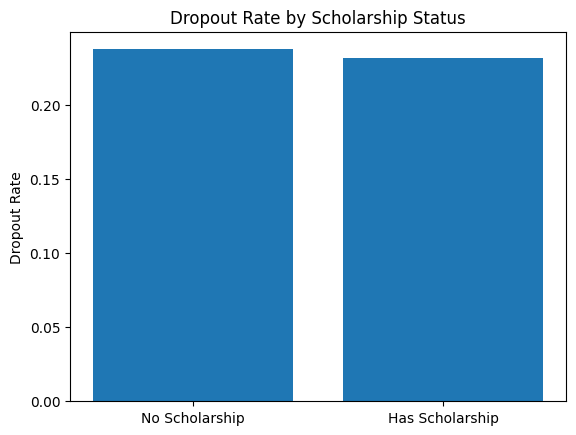

In [110]:
dropout_rate = df.groupby('has_scholarship')['Dropout'].mean()

plt.figure()
plt.bar(['No Scholarship', 'Has Scholarship'], dropout_rate.values)
plt.title("Dropout Rate by Scholarship Status")
plt.ylabel("Dropout Rate")
plt.show()

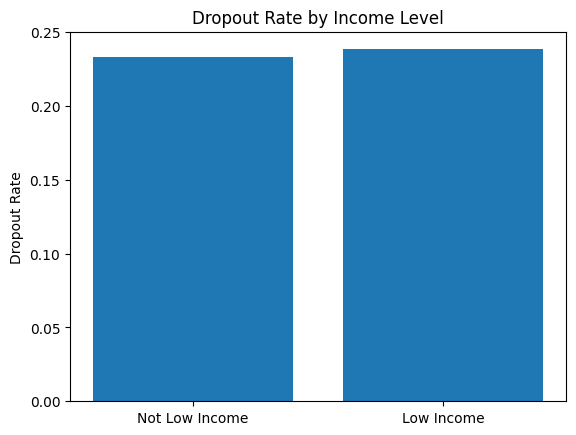

In [111]:
income_rate = df.groupby('low_income')['Dropout'].mean()

plt.figure()
plt.bar(income_rate.index.map({0: 'Not Low Income', 1: 'Low Income'}), income_rate.values)
plt.title("Dropout Rate by Income Level")
plt.ylabel("Dropout Rate")
plt.show()

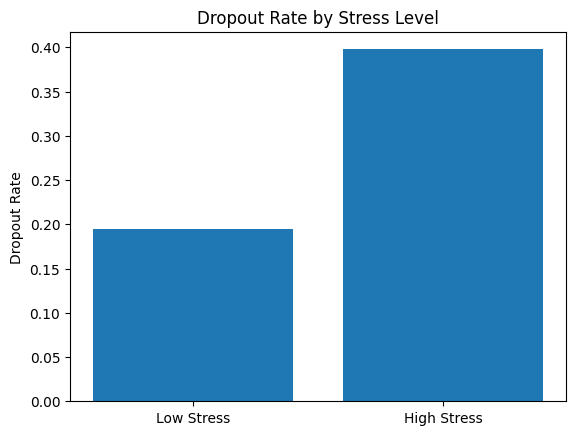

In [112]:
stress_rate = df.groupby('high_stress')['Dropout'].mean()

plt.figure()
plt.bar(stress_rate.index.map({0: 'Low Stress', 1: 'High Stress'}), stress_rate.values)
plt.title("Dropout Rate by Stress Level")
plt.ylabel("Dropout Rate")
plt.show()

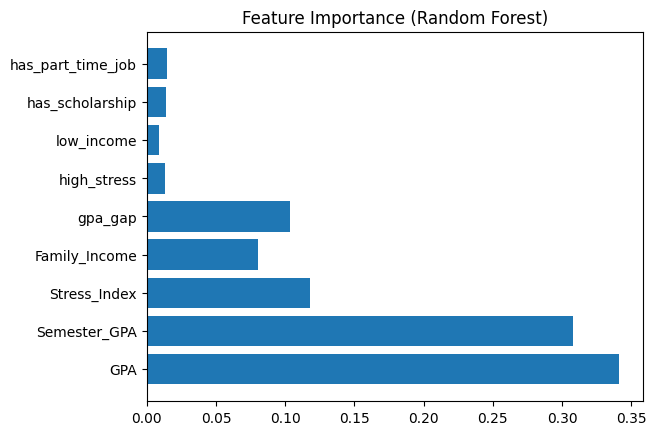

In [113]:
importances = best_rf.feature_importances_

plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [115]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())

GPA                  0
Semester_GPA         0
Stress_Index         0
Family_Income        0
gpa_gap              0
high_stress          0
low_income           0
has_scholarship      0
has_part_time_job    0
dtype: int64
GPA                  0
Semester_GPA         0
Stress_Index         0
Family_Income        0
gpa_gap              0
high_stress          0
low_income           0
has_scholarship      0
has_part_time_job    0
dtype: int64


Both the Logistic regression report and the random forest had approx 80% accuracy. With that being said, educational facilities coyld use these models to help predict deropout rates with these variables. From the feature importance we can see that academic performance, stress levels and financials are all important risk factors.

#Model Selection
Based on my findings, I would choose the Logistic regression moel, because of the higher accuracy value. The values were super close though, so in the future I would most likely add more features for each system to find correlations. ALso, a lot of the data that was missing was either removed or imported as the mean, which can throw off some values.

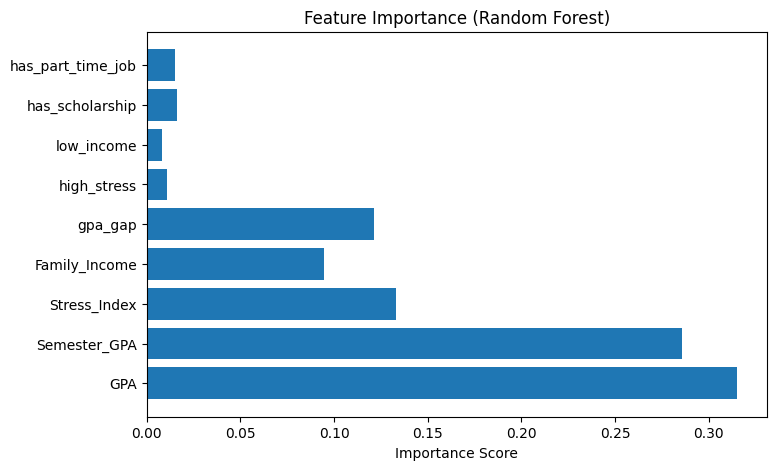

In [ ]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X_train.columns

plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

In [117]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()

specificity = tn / (tn + fp)
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print("Specificity:", specificity)
print("False Positive Rate:", fpr)
print("False Negative Rate:", fnr)

Specificity: 0.9326357096141269
False Positive Rate: 0.06736429038587312
False Negative Rate: 0.613588110403397


## 8. Next Steps & Reflection
[ When reviewing the models, i made sure to consider any bias within the data.
First i recognize that the stress levels are up for interpretation, but they are used as a baseline in my data.
Also, categories like income and part time job are a bias reflection in the data and 
really shouldn't be used to determine drop out rates as a final say.]

##Business recommendations
[
In order to keep students in school based on my findings, I would reccomend,
sharing these findings with students so they are aware of their potential risk of 
dropping out. After making students aware, schools should provide support and guidance
to help students regulate stress, difficult schedules and financial troubles.
]

#conclusion
[ In the graphs we can see that academic performance, workload and stress levels are all key 
 factors in dropout rates. As far as my income analysis, I did not see any substantial
 indicators suggesting that lower income results in a higher drop out rate.
 Academic performance, worload and stress levels were also ranked higher in the feature importance score
 relative to income level. Overall, my models also performed relatively well. The grid search 
 addition created a better accuraccy level.]